<a href="https://colab.research.google.com/github/ibrahimhanifceker/YZ50Codes/blob/main/YZ50Hafta6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. MLP kodunu classlara ayirma

In [285]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [286]:
import os

if not os.path.exists("names.txt"):
    !wget https://raw.githubusercontent.com/karpathy/makemore/refs/heads/master/names.txt

print("names.txt is downloaded")

names.txt is downloaded


In [287]:
words = open("names.txt", 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
chars = ['.'] + chars
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)

In [288]:
import random
random.seed(42)
random.shuffle(words)

In [289]:
context_size = 3

def build_dataset(words):
    x, y = [], []
    for word in words:
        context = [0] * context_size
        for ch in word + '.':
            idx = stoi[ch]
            x.append(context)
            y.append(idx)
            context = context[1:] + [idx]
    x = torch.tensor(x)
    y = torch.tensor(y)
    return x, y

tr_split = int(0.8 * len(words))
dev_split = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:tr_split])
Xdev, Ydev = build_dataset(words[tr_split:dev_split])
Xte, Yte = build_dataset(words[dev_split:])

In [290]:
class Linear:

    def __init__(self, in_features, out_features, bias=True):
        self.weight = torch.randn((in_features, out_features)) / in_features**0.5
        self.bias = torch.randn((out_features,)) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d:

    def __init__(self, num_features, eps=1e-05, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(num_features)
        self.beta = torch.zeros(num_features)
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(dim=0, keepdim=True)
            xvar = x.var(dim=0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xnorm = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xnorm + self.beta
        if self.training:
            with torch.inference_mode():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, idx):
        self.out = self.weight[idx]
        return self.out

    def parameters(self):
        return [self.weight]

class Flatten:

    def __call__(self, x):
        self.out = x.reshape(len(x), -1)
        return self.out

    def parameters(self):
        return []

class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [param for layer in self.layers for param in layer.parameters()]

In [291]:
torch.manual_seed(42);

In [292]:
emb_dim = 10
hidden_dim = 200

model = Sequential([
    Embedding(vocab_size, emb_dim),
    Flatten(),
    Linear(emb_dim * context_size, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    Linear(hidden_dim, vocab_size)
])

with torch.inference_mode():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(param.nelement() for param in parameters))
for param in parameters:
    param.requires_grad = True

12097


In [293]:
epochs = 200000
batch_size = 32
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    Xb, Yb = Xtr[idx], Ytr[idx]
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    loss_vals.append(loss.log10().item())

    for param in parameters:
        param.grad = None

    loss.backward()

    lr = 0.1 if epoch < epochs * 3/4 else 0.01
    for param in parameters:
        param.data += -lr * param.grad

    if epoch % (epochs / 20) == 0:
        print(f"Epoch: {epoch:7d}/{epochs:7d} | Loss: {loss:.4f}")

Epoch:       0/ 200000 | Loss: 3.6123
Epoch:   10000/ 200000 | Loss: 2.2514
Epoch:   20000/ 200000 | Loss: 2.2134
Epoch:   30000/ 200000 | Loss: 2.1166
Epoch:   40000/ 200000 | Loss: 2.4739
Epoch:   50000/ 200000 | Loss: 1.9872
Epoch:   60000/ 200000 | Loss: 1.7952
Epoch:   70000/ 200000 | Loss: 2.3035
Epoch:   80000/ 200000 | Loss: 2.1824
Epoch:   90000/ 200000 | Loss: 2.1404
Epoch:  100000/ 200000 | Loss: 2.1920
Epoch:  110000/ 200000 | Loss: 2.2182
Epoch:  120000/ 200000 | Loss: 1.9509
Epoch:  130000/ 200000 | Loss: 2.1866
Epoch:  140000/ 200000 | Loss: 2.5230
Epoch:  150000/ 200000 | Loss: 2.2446
Epoch:  160000/ 200000 | Loss: 1.9806
Epoch:  170000/ 200000 | Loss: 1.8113
Epoch:  180000/ 200000 | Loss: 1.8983
Epoch:  190000/ 200000 | Loss: 1.7139


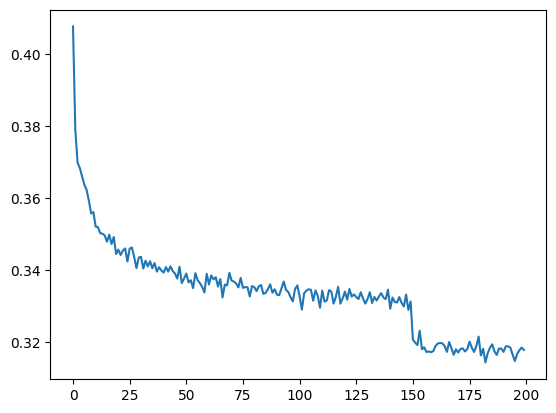

In [294]:
 plt.plot(torch.tensor(loss_vals).reshape(-1, 1000).mean(dim=1));

In [295]:
for layer in model.layers:
    layer.training = False

In [296]:
@torch.inference_mode()
def get_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

get_loss("train")
get_loss("dev")

train 2.058725118637085
dev 2.1081697940826416


In [297]:
num_names = 20

for _ in range(num_names):
    context = [0] * context_size
    name = []
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        idx = torch.multinomial(probs, num_samples=1).item()
        if idx == 0:
            break
        name.append(itos[idx])
        context = context[1:] + [idx]
    print(''.join(name))

kei
salvun
teon
lyn
adelia
jnika
halle
keymailee
sawalys
willia
aya
lal
demin
core
jasmari
kashaveon
talex
yalexleigh
haiveeralyn
ker


# 2. Context boyutu 3 -> 8

In [298]:
context_size = 8

def build_dataset(words):
    x, y = [], []
    for word in words:
        context = [0] * context_size
        for ch in word + '.':
            idx = stoi[ch]
            x.append(context)
            y.append(idx)
            context = context[1:] + [idx]
    x = torch.tensor(x)
    y = torch.tensor(y)
    return x, y

tr_split = int(0.8 * len(words))
dev_split = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:tr_split])
Xdev, Ydev = build_dataset(words[tr_split:dev_split])
Xte, Yte = build_dataset(words[dev_split:])

In [299]:
torch.manual_seed(42);

In [300]:
emb_dim = 10
hidden_dim = 200

model = Sequential([
    Embedding(vocab_size, emb_dim),
    Flatten(),
    Linear(emb_dim * context_size, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    Linear(hidden_dim, vocab_size)
])

with torch.inference_mode():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(param.nelement() for param in parameters))
for param in parameters:
    param.requires_grad = True

22097


In [301]:
epochs = 200000
batch_size = 32
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    Xb, Yb = Xtr[idx], Ytr[idx]
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    loss_vals.append(loss.log10().item())

    for param in parameters:
        param.grad = None

    loss.backward()

    lr = 0.1 if epoch < epochs * 3/4 else 0.01
    for param in parameters:
        param.data += -lr * param.grad

    if epoch % (epochs / 20) == 0:
        print(f"Epoch: {epoch:7d}/{epochs:7d} | Loss: {loss:.4f}")

Epoch:       0/ 200000 | Loss: 3.7847
Epoch:   10000/ 200000 | Loss: 2.0227
Epoch:   20000/ 200000 | Loss: 2.0045
Epoch:   30000/ 200000 | Loss: 1.7460
Epoch:   40000/ 200000 | Loss: 1.9717
Epoch:   50000/ 200000 | Loss: 1.9949
Epoch:   60000/ 200000 | Loss: 2.0298
Epoch:   70000/ 200000 | Loss: 1.9090
Epoch:   80000/ 200000 | Loss: 2.6236
Epoch:   90000/ 200000 | Loss: 1.8628
Epoch:  100000/ 200000 | Loss: 2.1360
Epoch:  110000/ 200000 | Loss: 1.8880
Epoch:  120000/ 200000 | Loss: 1.9967
Epoch:  130000/ 200000 | Loss: 2.1359
Epoch:  140000/ 200000 | Loss: 2.3116
Epoch:  150000/ 200000 | Loss: 1.9562
Epoch:  160000/ 200000 | Loss: 2.1903
Epoch:  170000/ 200000 | Loss: 1.6476
Epoch:  180000/ 200000 | Loss: 2.0732
Epoch:  190000/ 200000 | Loss: 2.0627


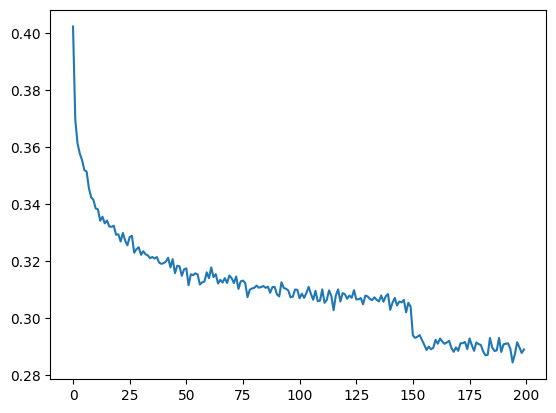

In [302]:
 plt.plot(torch.tensor(loss_vals).reshape(-1, 1000).mean(dim=1));

In [303]:
for layer in model.layers:
    layer.training = False

In [304]:
@torch.inference_mode()
def get_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

get_loss("train")
get_loss("dev")

train 1.9184144735336304
dev 2.030029296875


In [305]:
num_names = 20

for _ in range(num_names):
    context = [0] * context_size
    name = []
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        idx = torch.multinomial(probs, num_samples=1).item()
        if idx == 0:
            break
        name.append(itos[idx])
        context = context[1:] + [idx]
    print(''.join(name))

kasen
kahariah
dawglyn
mckinniseus
giahlar
airington
rosaliah
aaiden
raylin
kestlar
kayzlee
ustina
azakiyah
krexleigh
aeris
treinan
kennex
finnan
andmexri
ilmannabe


# 3. Wavenet Kurma

In [306]:
class Linear:

    def __init__(self, in_features, out_features, bias=True):
        self.weight = torch.randn((in_features, out_features)) / in_features**0.5
        self.bias = torch.randn((out_features,)) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d:

    def __init__(self, num_features, eps=1e-05, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(num_features)
        self.beta = torch.zeros(num_features)
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

    def __call__(self, x):
        if self.training:
            xmean = x.mean(dim=0, keepdim=True)
            xvar = x.var(dim=0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xnorm = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xnorm + self.beta
        if self.training:
            with torch.inference_mode():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, idx):
        self.out = self.weight[idx]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.reshape(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(dim=1)
        self.out = x
        return self.out

    def parameters(self):
        return []

class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [param for layer in self.layers for param in layer.parameters()]

In [307]:
emb_dim = 10
hidden_dim = 200

model = Sequential([
    Embedding(vocab_size, emb_dim),
    FlattenConsecutive(2), Linear(emb_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    FlattenConsecutive(2), Linear(hidden_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    FlattenConsecutive(2), Linear(hidden_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    Linear(hidden_dim, vocab_size)
])

with torch.inference_mode():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(param.nelement() for param in parameters))
for param in parameters:
    param.requires_grad = True

170897


In [308]:
idx = torch.randint(0, len(Xtr), (4,))
Xb, Yb = Xtr[idx], Ytr[idx]
logits = model(Xb)

In [309]:
for layer in model.layers:
    print(layer.__class__.__name__, ":", tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 200)
BatchNorm1d : (4, 4, 200)
Tanh : (4, 4, 200)
FlattenConsecutive : (4, 2, 400)
Linear : (4, 2, 200)
BatchNorm1d : (4, 2, 200)
Tanh : (4, 2, 200)
FlattenConsecutive : (4, 400)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


In [310]:
# Ilk Flatten 8 karakteri ikiserli 4 gruba ayiriyor bu yuzden shape[1] 8 -> 4 oluyor.
# Ikinci Flatten 4 grubu ikiserli esleyip 2 gruba ayiriyor bu yuzden shape[1] 4 -> 2 oluyor.
# Son Flatten kalan 2 grubu tek birgruba topluyor bu yuzden shape[1] 2 -> 1 oluyor.

# 4. BatchNormdaki Hata

In [311]:
emb_dim = 10
hidden_dim = 68

model = Sequential([
    Embedding(vocab_size, emb_dim),
    FlattenConsecutive(2), Linear(emb_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    FlattenConsecutive(2), Linear(hidden_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    FlattenConsecutive(2), Linear(hidden_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    Linear(hidden_dim, vocab_size)
])

with torch.inference_mode():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(param.nelement() for param in parameters))
for param in parameters:
    param.requires_grad = True

22397


In [312]:
epochs = 200000
batch_size = 32
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    Xb, Yb = Xtr[idx], Ytr[idx]
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    loss_vals.append(loss.log10().item())

    for param in parameters:
        param.grad = None

    loss.backward()

    lr = 0.1 if epoch < epochs * 3/4 else 0.01
    for param in parameters:
        param.data += -lr * param.grad

    if epoch % (epochs / 20) == 0:
        print(f"Epoch: {epoch:7d}/{epochs:7d} | Loss: {loss:.4f}")

Epoch:       0/ 200000 | Loss: 3.4321
Epoch:   10000/ 200000 | Loss: 1.9147
Epoch:   20000/ 200000 | Loss: 1.9323
Epoch:   30000/ 200000 | Loss: 2.0387
Epoch:   40000/ 200000 | Loss: 2.3549
Epoch:   50000/ 200000 | Loss: 2.0676
Epoch:   60000/ 200000 | Loss: 1.8490
Epoch:   70000/ 200000 | Loss: 2.2494
Epoch:   80000/ 200000 | Loss: 2.1867
Epoch:   90000/ 200000 | Loss: 2.3441
Epoch:  100000/ 200000 | Loss: 1.7016
Epoch:  110000/ 200000 | Loss: 2.1059
Epoch:  120000/ 200000 | Loss: 2.0802
Epoch:  130000/ 200000 | Loss: 2.2839
Epoch:  140000/ 200000 | Loss: 2.3345
Epoch:  150000/ 200000 | Loss: 2.0194
Epoch:  160000/ 200000 | Loss: 1.8836
Epoch:  170000/ 200000 | Loss: 2.0609
Epoch:  180000/ 200000 | Loss: 2.0721
Epoch:  190000/ 200000 | Loss: 2.1453


In [313]:
for layer in model.layers:
    layer.training = False

In [314]:
@torch.inference_mode()
def get_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

get_loss("train")
get_loss("dev")

train 1.9413857460021973
dev 2.0323522090911865


In [315]:
class Linear:

    def __init__(self, in_features, out_features, bias=True):
        self.weight = torch.randn((in_features, out_features)) / in_features**0.5
        self.bias = torch.randn((out_features,)) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([self.bias] if self.bias is not None else [])

class BatchNorm1d:

    def __init__(self, num_features, eps=1e-05, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        self.gamma = torch.ones(num_features)
        self.beta = torch.zeros(num_features)
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

    def __call__(self, x):
        if self.training:
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3:
                dim = (0, 1)
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xnorm = (x - xmean) / torch.sqrt(xvar + self.eps)
        self.out = self.gamma * xnorm + self.beta
        if self.training:
            with torch.inference_mode():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, idx):
        self.out = self.weight[idx]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        x = x.reshape(B, T//self.n, C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(dim=1)
        self.out = x
        return self.out

    def parameters(self):
        return []

class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [param for layer in self.layers for param in layer.parameters()]

In [316]:
epochs = 200000
batch_size = 32
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    Xb, Yb = Xtr[idx], Ytr[idx]
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    loss_vals.append(loss.log10().item())

    for param in parameters:
        param.grad = None

    loss.backward()

    lr = 0.1 if epoch < epochs * 3/4 else 0.01
    for param in parameters:
        param.data += -lr * param.grad

    if epoch % (epochs / 20) == 0:
        print(f"Epoch: {epoch:7d}/{epochs:7d} | Loss: {loss:.4f}")

Epoch:       0/ 200000 | Loss: 1.9292
Epoch:   10000/ 200000 | Loss: 2.1053
Epoch:   20000/ 200000 | Loss: 1.8259
Epoch:   30000/ 200000 | Loss: 1.7848
Epoch:   40000/ 200000 | Loss: 1.8255
Epoch:   50000/ 200000 | Loss: 1.9058
Epoch:   60000/ 200000 | Loss: 1.5653
Epoch:   70000/ 200000 | Loss: 2.1018
Epoch:   80000/ 200000 | Loss: 2.0644
Epoch:   90000/ 200000 | Loss: 1.6725
Epoch:  100000/ 200000 | Loss: 1.5718
Epoch:  110000/ 200000 | Loss: 2.2442
Epoch:  120000/ 200000 | Loss: 1.9219
Epoch:  130000/ 200000 | Loss: 2.2435
Epoch:  140000/ 200000 | Loss: 2.3670
Epoch:  150000/ 200000 | Loss: 2.0413
Epoch:  160000/ 200000 | Loss: 2.2737
Epoch:  170000/ 200000 | Loss: 1.8899
Epoch:  180000/ 200000 | Loss: 2.0695
Epoch:  190000/ 200000 | Loss: 1.9047


In [317]:
for layer in model.layers:
    layer.training = False

In [318]:
@torch.inference_mode()
def get_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

get_loss("train")
get_loss("dev")

train 1.8628618717193604
dev 2.034747838973999


# 5. Modeli buyutme

In [319]:
torch.manual_seed(42)

In [320]:
emb_dim = 24
hidden_dim = 128

model = Sequential([
    Embedding(vocab_size, emb_dim),
    FlattenConsecutive(2), Linear(emb_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    FlattenConsecutive(2), Linear(hidden_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    FlattenConsecutive(2), Linear(hidden_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    Linear(hidden_dim, vocab_size)
])

with torch.inference_mode():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(param.nelement() for param in parameters))
for param in parameters:
    param.requires_grad = True

76579


In [321]:
epochs = 200000
batch_size = 32
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    Xb, Yb = Xtr[idx], Ytr[idx]
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    loss_vals.append(loss.log10().item())

    for param in parameters:
        param.grad = None

    loss.backward()

    lr = 0.1 if epoch < epochs * 3/4 else 0.01
    for param in parameters:
        param.data += -lr * param.grad

    if epoch % (epochs / 20) == 0:
        print(f"Epoch: {epoch:7d}/{epochs:7d} | Loss: {loss:.4f}")

Epoch:       0/ 200000 | Loss: 4.6212
Epoch:   10000/ 200000 | Loss: 2.1471
Epoch:   20000/ 200000 | Loss: 1.5086
Epoch:   30000/ 200000 | Loss: 2.1991
Epoch:   40000/ 200000 | Loss: 2.0678
Epoch:   50000/ 200000 | Loss: 1.8112
Epoch:   60000/ 200000 | Loss: 2.3209
Epoch:   70000/ 200000 | Loss: 1.9109
Epoch:   80000/ 200000 | Loss: 1.5972
Epoch:   90000/ 200000 | Loss: 1.8337
Epoch:  100000/ 200000 | Loss: 2.0202
Epoch:  110000/ 200000 | Loss: 2.2274
Epoch:  120000/ 200000 | Loss: 1.8608
Epoch:  130000/ 200000 | Loss: 2.1748
Epoch:  140000/ 200000 | Loss: 1.7984
Epoch:  150000/ 200000 | Loss: 2.0833
Epoch:  160000/ 200000 | Loss: 2.1612
Epoch:  170000/ 200000 | Loss: 1.7996
Epoch:  180000/ 200000 | Loss: 1.7231
Epoch:  190000/ 200000 | Loss: 1.8489


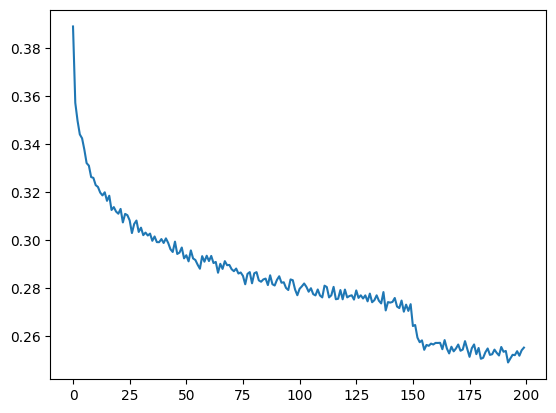

In [322]:
 plt.plot(torch.tensor(loss_vals).reshape(-1, 1000).mean(dim=1));

In [323]:
for layer in model.layers:
    layer.training = False

In [324]:
@torch.inference_mode()
def get_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

get_loss("train")
get_loss("dev")

train 1.7673869132995605
dev 1.9882047176361084


In [325]:
num_names = 20

for _ in range(num_names):
    context = [0] * context_size
    name = []
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        idx = torch.multinomial(probs, num_samples=1).item()
        if idx == 0:
            break
        name.append(itos[idx])
        context = context[1:] + [idx]
    print(''.join(name))

jerrel
annamya
sverita
nolme
ida
rmion
raquel
ettel
kellyn
hamed
hilda
jahmir
klorley
mooben
menda
maddie
adalyne
hangelone
killion
kierstine


0. Model turu ---------- Parametre sayisi -- Dev loss
1. Context 3 MLP ------- 12097 ------------- 2.1081697940826416
2. Context 8 MLP ------- 22097 ------------- 2.030029296875
3. Context 8 Wavenet --- 76579 ------------- 1.9882047176361084


# 6. Turkce Isimleri Wavenet ile Egitme

In [326]:
import os

if not os.path.exists("YZ50Codes"):
    !git clone https://github.com/ibrahimhanifceker/YZ50Codes.git

In [327]:
def turkish_lower(s):
    res = ''.join(['i' if ch == 'İ' else 'ı' if ch == 'I' else ch.lower() for ch in s])
    return res

In [328]:
import pandas as pd

man_names_file = pd.read_csv("YZ50Codes/hafta-3/TR_Man_Name.csv")
woman_names_file = pd.read_csv("YZ50Codes/hafta-3/TR_Woman_Name.csv")

man_names_double = list(man_names_file.iloc[:, 0])
woman_names_double = list(woman_names_file.iloc[:, 0])

man_names = [turkish_lower(name) for names in man_names_double for name in names.split()]
woman_names = [turkish_lower(name) for names in woman_names_double for name in names.split()]

len(man_names), len(woman_names)

(239300, 232675)

In [329]:
include_man = True
include_woman = True

In [330]:
names_duplicate = (man_names if include_man else []) + (woman_names if include_woman else [])

names = list(set(names_duplicate))

len(names)

135502

In [331]:
chars = sorted(list(set(''.join(names))))
chars = ['.'] + chars
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)

In [332]:
def build_dataset(words):
    x, y = [], []
    for word in words:
        context = [0] * context_size
        for ch in word + '.':
            idx = stoi[ch]
            x.append(context)
            y.append(idx)
            context = context[1:] + [idx]
    x = torch.tensor(x)
    y = torch.tensor(y)
    return x, y

import random
random.seed(42)
random.shuffle(names)

train_split = int(0.8 * len(names))
dev_split = int(0.9 * len(names))

Xtr, Ytr = build_dataset(names[:train_split])
Xdev, Ydev = build_dataset(names[train_split:dev_split])
Xte, Yte = build_dataset(names[dev_split:])

In [333]:
torch.manual_seed(42)

In [334]:
emb_dim = 24
hidden_dim = 128

model = Sequential([
    Embedding(vocab_size, emb_dim),
    FlattenConsecutive(2), Linear(emb_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    FlattenConsecutive(2), Linear(hidden_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    FlattenConsecutive(2), Linear(hidden_dim * 2, hidden_dim, bias=False), BatchNorm1d(hidden_dim), Tanh(),
    Linear(hidden_dim, vocab_size)
])

with torch.inference_mode():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(param.nelement() for param in parameters))
for param in parameters:
    param.requires_grad = True

77497


In [280]:
epochs = 200000
batch_size = 32
loss_vals = []

for epoch in range(epochs):
    idx = torch.randint(0, len(Xtr), (batch_size,))
    Xb, Yb = Xtr[idx], Ytr[idx]
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    loss_vals.append(loss.log10().item())

    for param in parameters:
        param.grad = None

    loss.backward()

    lr = 0.1 if epoch < epochs * 3/4 else 0.01
    for param in parameters:
        param.data += -lr * param.grad

    if epoch % (epochs / 20) == 0:
        print(f"Epoch: {epoch:7d}/{epochs:7d} | Loss: {loss:.4f}")

Epoch:       0/ 200000 | Loss: 4.2317
Epoch:   10000/ 200000 | Loss: 1.7958
Epoch:   20000/ 200000 | Loss: 2.5039
Epoch:   30000/ 200000 | Loss: 2.4714
Epoch:   40000/ 200000 | Loss: 2.1401
Epoch:   50000/ 200000 | Loss: 2.2185
Epoch:   60000/ 200000 | Loss: 2.0464
Epoch:   70000/ 200000 | Loss: 2.2661
Epoch:   80000/ 200000 | Loss: 2.2967
Epoch:   90000/ 200000 | Loss: 2.1816
Epoch:  100000/ 200000 | Loss: 2.5194
Epoch:  110000/ 200000 | Loss: 1.8834
Epoch:  120000/ 200000 | Loss: 2.2723
Epoch:  130000/ 200000 | Loss: 1.8231
Epoch:  140000/ 200000 | Loss: 1.8365
Epoch:  150000/ 200000 | Loss: 2.1435
Epoch:  160000/ 200000 | Loss: 1.9305
Epoch:  170000/ 200000 | Loss: 2.1497
Epoch:  180000/ 200000 | Loss: 2.4290
Epoch:  190000/ 200000 | Loss: 1.9348


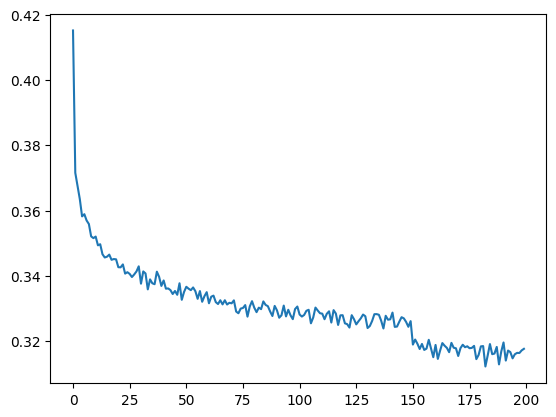

In [281]:
 plt.plot(torch.tensor(loss_vals).reshape(-1, 1000).mean(dim=1));

In [282]:
for layer in model.layers:
    layer.training = False

In [283]:
@torch.inference_mode()
def get_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

get_loss("train")
get_loss("dev")

train 2.0668647289276123
dev 2.099912643432617


In [284]:
num_names = 20

for _ in range(num_names):
    context = [0] * context_size
    name = []
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)
        idx = torch.multinomial(probs, num_samples=1).item()
        if idx == 0:
            break
        name.append(itos[idx])
        context = context[1:] + [idx]
    print(''.join(name))

rohye
şafiye
ijyam
özlok
emirey
abtem
ümmuselli
ferdire
özşeşen
gemrine
beri
suttua
hacıhal
sancak
ifalıt
sairbian
fehriye
fermauc
devo
herina


Eski turcke dev loss: 2.2548351287841797

Wavenet turkce dev loss: 2.099912643432617